In [58]:
import os
import glob
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [74]:
train_dir = 'plant_dataset/train'
val_dir = 'plant_dataset/valid'

image_size = (128,128)
batch_size = 32

trainDataGen = ImageDataGenerator(rescale=1.0/255)
valDataGen = ImageDataGenerator(rescale=1.0/255)

train_data = trainDataGen.flow_from_directory(
    train_dir,
    target_size = image_size,
    batch_size = batch_size,
    class_mode='categorical'
)
val_data = valDataGen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size= batch_size,
    class_mode='categorical',
    shuffle=False 
)

test_dir = 'plant_dataset/test'
test_images = []
test_images_paths = glob.glob(test_dir + "/*.JPG")
for img_path in test_images_paths:
    image = load_img(img_path, target_size=(128,128))
    image_array = img_to_array(image)/255.0
    test_images.append(image_array)
test_images = np.array(test_images)

print(len(test_images))

Found 18504 images belonging to 10 classes.
Found 4626 images belonging to 10 classes.
33


In [61]:
len(train_data.class_indices)

10

In [62]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_data.class_indices), activation='softmax')
           
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,610 (28.20 MB)

 Trainable params: 7,393,610 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
history = model.fit(train_data, validation_data=(val_data), epochs=3);

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
579/579 ━━━━━━━━━━━━━━━━━━━━ 231s 394ms/step - accuracy: 0.5653 - loss: 1.2504 - val_accuracy: 0.9010 - val_loss: 0.3109
Epoch 2/3
579/579 ━━━━━━━━━━━━━━━━━━━━ 229s 395ms/step - accuracy: 0.8595 - loss: 0.4127 - val_accuracy: 0.9122 - val_loss: 0.2717
Epoch 3/3
579/579 ━━━━━━━━━━━━━━━━━━━━ 2008s 3s/step - accuracy: 0.8980 - loss: 0.2873 - val_accuracy: 0.9447 - val_loss: 0.1752


In [ ]:
val_loss, val_accuracy = model.evaluate(val_data)
print(val_loss, val_accuracy)

145/145 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.9423 - loss: 0.1797
0.17521977424621582 0.9446606040000916


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


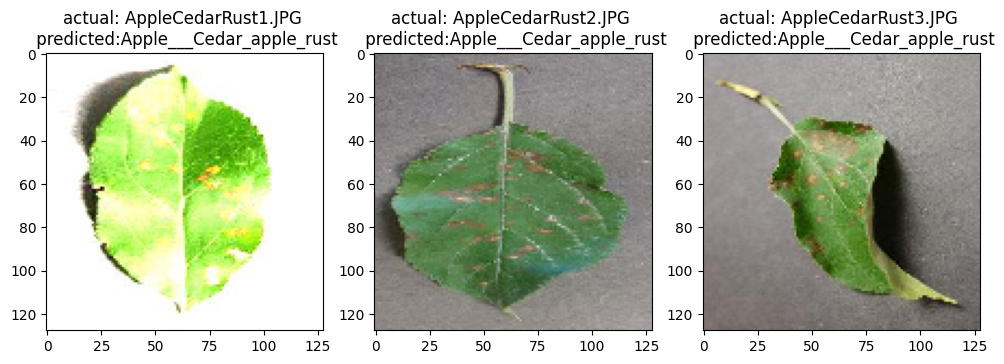

In [66]:
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
class_labels = list(train_data.class_indices.keys())

plt.figure(figsize=(10,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(test_images[i])
    filename =os.path.basename(test_images_paths[i])
    label = class_labels[predicted_classes[i]]
    plt.title(f"actual: {filename} \n predicted:{label}")

plt.tight_layout()

In [75]:
import sklearn.metrics
from sklearn.metrics import classification_report
pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)
actual_classes = val_data.classes
print(classification_report(actual_classes, pred_classes))

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


145/145 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step
              precision    recall  f1-score   support

           0       0.92      0.86      0.88       504
           1       0.93      0.94      0.93       497
           2       0.93      0.94      0.94       440
           3       0.93      0.91      0.92       502
           4       0.94      0.93      0.94       454
           5       0.96      0.93      0.94       421
           6       0.92      1.00      0.95       456
           7       0.93      0.99      0.96       410
           8       1.00      0.99      0.99       477
           9       0.99      0.98      0.99       465

    accuracy                           0.94      4626
   macro avg       0.95      0.95      0.95      4626
weighted avg       0.94      0.94      0.94      4626



In [69]:
print(pred_classes)

[7 2 5 ... 7 3 8]


In [70]:
print(actual_classes)

[0 0 0 ... 9 9 9]
